In [30]:
mol = 'heh+'
basis = '6-31g'
method = 'fci'

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
import time

In [32]:
dt = 0.01
T = 200.0
numsteps = int(np.ceil(T/dt))
print("numsteps = " + str(numsteps))

# field parameters: 
freq = 0.25              # frequency
amp = 0.5                # amplitude
ncyc = 5.0               # number of cycles to keep field on

# Let us take the field to be
# amp * sin(2 * pi * freq * t) so that the period is T = 1 / freq.
# Thus we will keep the field on for ncyc * T = ncyc / freq a.u.,
# which translates into ncyc / (dt * freq) time steps.

stepoff = int(np.ceil(ncyc / (dt * freq)))
print("field will be on for " + str(stepoff) + " time steps")

numsteps = 20000
field will be on for 2000 time steps


In [33]:
fname = method + '_' + mol + '_' + basis + '.npz'
print(fname)

fci_heh+_6-31g.npz


In [34]:
prefix = './psi4data/'
psi4data = np.load(prefix + fname)

In [35]:
psi4data['ham']

array([-2.93231075, -2.14209775, -1.96404284, -1.41552484, -1.35282616,
       -0.99688458, -0.6654203 , -0.57566881, -0.08763561,  0.08179299,
        0.21715018,  0.44229521,  0.69881705,  0.90207512,  1.09915501,
        1.42731566])

In [36]:
print(list(psi4data.keys()))

['C', 'S', 'AOdipmat', 'CIdimatz', 'Bten', 'ham']


In [37]:
drcCI = psi4data['Bten'].shape[0]
drc = psi4data['Bten'].shape[2]

In [38]:
print(drcCI)
print(drc)

16
4


In [39]:
# propagate starting with a particular initial condition ic
statesCI = np.zeros((drcCI, numsteps+1), dtype=np.complex128)
statesCI[0,0] = 1.0
cnt = 0

# store the propagators
# could modify this later to store only when field is on
fieldprop = np.zeros((drcCI, drcCI, numsteps), dtype=np.complex128)

# propagate solution forward in time
for j in range(numsteps):
    h = np.diag(psi4data['ham'])
    if (j < stepoff):
        field = amp * np.sin(2*np.pi*freq*j*dt)
        print("Time step j = " + str(j) + "; field strength = " + str(field)) 
        h += field * psi4data['CIdimatz']
        dd, vv = np.linalg.eigh(h)
        prop = vv @ np.diag(np.exp(-1j * dt * dd)) @ vv.conj().T
    else:
        prop = np.diag(np.exp(-1j * dt * psi4data['ham']))
    
    fieldprop[:, :, j] = prop
    statesCI[:,j+1] = prop @ statesCI[:,j]

Time step j = 0; field strength = 0.0
Time step j = 1; field strength = 0.007853658655910338
Time step j = 2; field strength = 0.015705379539064146
Time step j = 3; field strength = 0.023553225354821333
Time step j = 4; field strength = 0.03139525976465669
Time step j = 5; field strength = 0.03922954786392247
Time step j = 6; field strength = 0.04705415665925716
Time step j = 7; field strength = 0.054867155545522635
Time step j = 8; field strength = 0.06266661678215213
Time step j = 9; field strength = 0.07045061596879133
Time step j = 10; field strength = 0.07821723252011543
Time step j = 11; field strength = 0.08596455013970476
Time step j = 12; field strength = 0.09369065729286231
Time step j = 13; field strength = 0.10139364767825625
Time step j = 14; field strength = 0.10907162069827127
Time step j = 15; field strength = 0.1167226819279527
Time step j = 16; field strength = 0.1243449435824274
Time step j = 17; field strength = 0.13193652498268646
Time step j = 18; field strength =

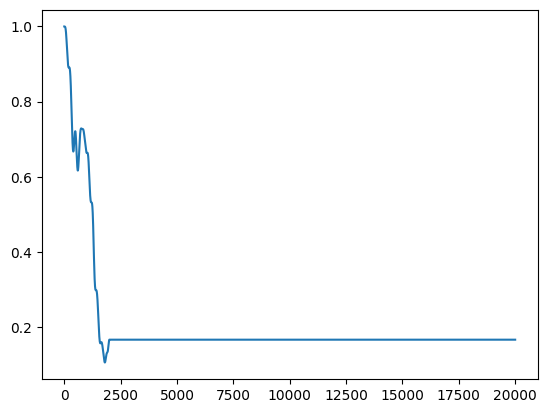

In [40]:
plt.plot(np.abs(statesCI[0,:]))
plt.show()

In [41]:
# compute and store all 1-RDMs
Bmat = psi4data['Bten'].reshape((drcCI**2, drc**2))
BmatT = Bmat.T
truerdms = np.zeros((numsteps+1, drc, drc), dtype=np.complex128)
for j in range(numsteps+1):
    a = statesCI[:, [j]]
    trueden = a @ a.conj().T
    truerdms[j, :, :] = (BmatT @ trueden.reshape((-1))).reshape((drc, drc))

In [42]:
# check at once whether all 1-RDM traces are close to 2
print( np.mean(np.abs(np.einsum('jaa->j',truerdms) - 2)) )

5.950261719783854e-13


In [43]:
# BmatT has drcCI**2 columns
# let us figure out which of these columns are actually non-trivial
colnorms = np.array( list( map( lambda j : np.linalg.norm(BmatT[:,j]), np.arange(drcCI**2, dtype=np.int16) ) ) )
goodcols = np.where(colnorms > 1e-14)[0]
badcols = np.where(colnorms <= 1e-14)[0]
diagcols = np.where(np.eye(drcCI).reshape((-1)))[0]
fincols = goodcols[~np.isin(goodcols, diagcols)]

In [44]:
zerostates = []
for j in range(drcCI):
    if np.linalg.norm(statesCI[j,:]) < 1e-10:
        zerostates.append(j)

In [45]:
print(zerostates)

[1, 3, 5, 8, 10, 13]


In [46]:
truedens = np.einsum('in,jn->ijn',statesCI,statesCI.conj())
truedenflat = truedens.reshape((drcCI**2, numsteps+1))

In [47]:
statesnorms = np.array( list( map( lambda j : np.linalg.norm(statesCI[j,:]), np.arange(drcCI, dtype=np.int16) ) ) )

In [48]:
statesCI.shape

(16, 20001)

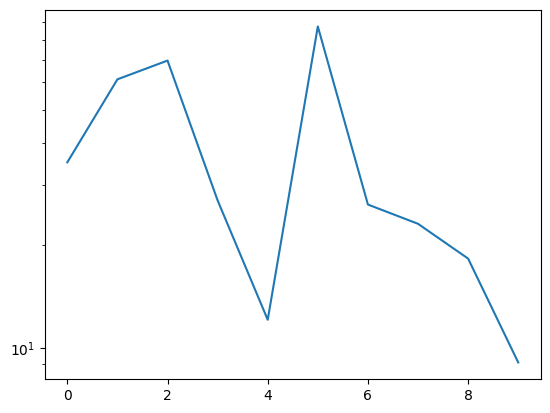

In [49]:
plt.semilogy(statesnorms[statesnorms>1e-10])
plt.show()

100


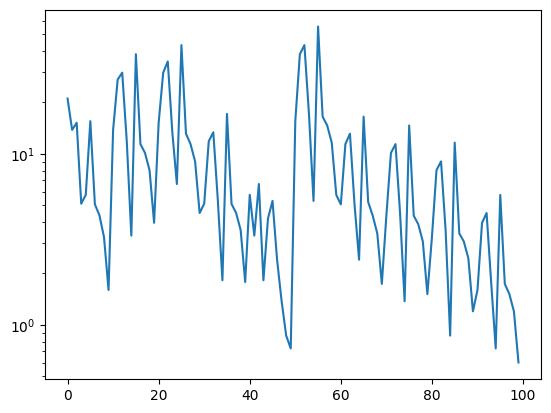

In [50]:
truedencolnorms = np.array( list( map( lambda j : np.linalg.norm(truedenflat[j,:]), np.arange(drcCI**2, dtype=np.int16) ) ) )
tdgc = np.where(truedencolnorms >= 1e-10)[0]
print(len(tdgc))
plt.semilogy(truedencolnorms[tdgc])
plt.show()

In [43]:
BmatTT = BmatT.reshape((drc**2, drcCI, drcCI))
def buildbigmat(J, ell):
    drc2 = drc**2
    Amat = np.eye(drcCI)
    out = [BmatT[:,tdgc]]
    for j in range(1, ell+1):
        Amat = Amat @ fieldprop[:,:,J - j]
        out.append( (Amat.conj() @ BmatTT @ Amat.T).reshape((drc**2, drcCI**2))[:,tdgc] )
    return np.concatenate(out, axis=0)

In [44]:
def lastblock(J, startell, endell):
    drc2 = drc**2
    Amat = np.eye(drcCI)
    out = []
    for j in range(1, endell+1):
        Amat = Amat @ fieldprop[:,:,J - j]
        if j >= startell:
            out.append( (Amat.conj() @ BmatTT @ Amat.T).reshape((drc**2, drcCI**2))[:,tdgc] )
        
    return np.concatenate(out, axis=0)
    

In [45]:
(buildbigmat(200, 2) @ truedenflat[tdgc,200]) - np.concatenate([truerdms[200].reshape((-1)),
                                                                truerdms[200-1].reshape((-1)),
                                                                truerdms[200-2].reshape((-1))])

array([ 6.66133815e-16+1.02163258e-18j, -5.55111512e-17-1.38777878e-16j,
       -5.55111512e-17-1.04083409e-17j, -2.77555756e-17+4.33680869e-18j,
       -5.55111512e-17+0.00000000e+00j,  2.77555756e-17-3.71582766e-19j,
       -2.77555756e-17+0.00000000e+00j, -6.93889390e-18-1.73472348e-18j,
       -2.22044605e-16+0.00000000e+00j,  0.00000000e+00-3.46944695e-18j,
        0.00000000e+00+3.19331421e-19j,  5.20417043e-18+0.00000000e+00j,
        1.38777878e-17+0.00000000e+00j,  0.00000000e+00+1.73472348e-18j,
        1.73472348e-18+0.00000000e+00j,  3.46944695e-18+4.65868121e-21j,
        7.77156117e-15-9.65207609e-18j, -1.83186799e-15+6.38378239e-16j,
       -6.10622664e-16+1.73472348e-16j,  3.26128013e-16-4.20670443e-17j,
       -1.94289029e-15-6.10622664e-16j,  4.16333634e-16-1.69216007e-18j,
        8.32667268e-17-1.90819582e-17j, -1.04083409e-16-2.60208521e-18j,
       -4.44089210e-16-1.66533454e-16j,  1.38777878e-16+8.67361738e-18j,
       -7.63278329e-17-1.86347248e-20j, -2.08166817

In [46]:
test = buildbigmat(100, 5)

In [78]:
test2 = np.loadtxt('bigmat.csv',delimiter=',',dtype=complex)

In [79]:
print( np.mean(np.abs( test - test2 )) )

7.105631870570549e-16


In [21]:
# test1 = buildbigmat(200, 1)
# test2 = buildbigmat(200, 2)
# r = lastblock(200, 2) 

# u1, s1, v1dag = np.linalg.svd(test1, full_matrices=False)
# v1 = v1dag.conj().T

# rorth = r - r @ v1 @ v1dag

# # 1. Perform the initial QR on transpose
# q, z_T = np.linalg.qr(rorth.conj().T, mode='reduced')

# # 2. Explicitly re-orthogonalize q against v1 to fix numerical leakage
# # This is essentially: q = q - v1 @ (v1.H @ q)
# q = q - v1 @ (v1.conj().T @ q)

# # 3. Re-normalize the columns of q
# q, _ = np.linalg.qr(q) 

# # 4. Re-calculate z based on the cleaned-up q
# # Since r_orth = z @ q.H, we have z = r_orth @ q
# z = rorth @ q

# # Build the core matrix K
# # k is the rank of M1 (32 in your case), m is the new block height (16)
# k, m = s1.shape[0], r.shape[0]
# top = np.hstack([np.diag(s1), np.zeros((k, m))])
# bot = np.hstack([r @ v1, z])
# kmat = np.vstack([top, bot])

# # SVD of core
# utilde, delta, vh_tilde = np.linalg.svd(kmat, full_matrices=False)

# # Update U and V
# # Using block_diag logic for U
# u_ext = np.block([
#     [u1, np.zeros((u1.shape[0], m))],
#     [np.zeros((m, u1.shape[1])), np.eye(m)]
# ])
# myu2 = u_ext @ utilde
# myv2 = np.hstack([v1, q]) @ vh_tilde.conj().T

# # check SVD
# print(np.linalg.norm(myu2 @ np.diag(delta) @ myv2.conj().T - test2))

# # Should be close to zero
# print(np.linalg.norm(myu2.conj().T @ myu2 - np.eye(myu2.shape[1])))

# # Should be close to zero
# print(np.linalg.norm(myv2.conj().T @ myv2 - np.eye(myv2.shape[1])))


In [22]:
def updatesvd(ell, u1, s1, v1, r):
    N = v1.shape[0]  # The maximum Hilbert space dimension
    k = s1.shape[0]
    m = r.shape[0]
    
    v1dag = v1.conj().T
    r_par = r @ v1
    rorth = r - r_par @ v1dag
    
    # Calculate a dynamic noise threshold based on the incoming block
    r_norm = np.linalg.norm(r)
    tol = 1e-12 * r_norm if r_norm > 1e-14 else 1e-12
    
    if k >= N or np.linalg.norm(rorth) < tol:
        # --- TALL REGIME / NO EXPANSION ---
        kmat = np.vstack([np.diag(s1), r_par])
        print("tall regime: ell = " + str(ell) + "; kmat.shape = " + str(kmat.shape))
        utilde, delta, vh_tilde = np.linalg.svd(kmat, full_matrices=False)
        
        rank_to_keep = min(len(delta), N)
        delta = delta[:rank_to_keep]
        utilde = utilde[:, :rank_to_keep]
        v_tilde = vh_tilde[:rank_to_keep, :].conj().T

        myu2 = np.vstack([u1 @ utilde[:k, :], utilde[k:, :]])
        myv2 = v1 @ v_tilde

    else:
        # --- EXPANSION REGIME ---
        # Instead of QR, use SVD on the residual to find true new dimensions
        print("expansion regime: ell = " + str(ell) + "; rorth.shape = " + str(rorth.shape))
        uq, sq, vq_h = np.linalg.svd(rorth, full_matrices=False)
        
        # Count meaningful new dimensions above the noise floor
        valid_dims = np.sum(sq > tol)
        
        # CRITICAL GUARDRAIL: Cap the added dimensions so k + new_dims <= N
        new_dims = min(valid_dims, N - k)
        
        if new_dims == 0:
            # Everything was noise or subspace is physically full
            kmat = np.vstack([np.diag(s1), r_par])
            print("expansion regime: ell = " + str(ell) + "; kmat.shape = " + str(kmat.shape))
            utilde, delta, vh_tilde = np.linalg.svd(kmat, full_matrices=False)
            
            rank_to_keep = min(len(delta), N)
            delta = delta[:rank_to_keep]
            utilde = utilde[:, :rank_to_keep]
            v_tilde = vh_tilde[:rank_to_keep, :].conj().T

            myu2 = np.vstack([u1 @ utilde[:k, :], utilde[k:, :]])
            myv2 = v1 @ v_tilde
            
        else:
            # Extract exactly the safe number of new orthogonal basis vectors
            q = vq_h[:new_dims, :].conj().T
            
            # Re-orthogonalize against v1 to remove floating point leakage
            for _ in range(2):
                q = q - v1 @ (v1dag @ q)
                q, _ = np.linalg.qr(q)
                
            z = rorth @ q
            
            top = np.hstack([np.diag(s1), np.zeros((k, q.shape[1]))])
            bot = np.hstack([r_par, z])
            kmat = np.vstack([top, bot])
            
            print("expansion regime: ell = " + str(ell) + "; kmat.shape = " + str(kmat.shape))
            utilde, delta, vh_tilde = np.linalg.svd(kmat, full_matrices=False)
            
            # Strict truncation to N
            rank_to_keep = min(len(delta), N)
            delta = delta[:rank_to_keep]
            utilde = utilde[:, :rank_to_keep]
            v_tilde = vh_tilde[:rank_to_keep, :].conj().T

            myu2 = np.vstack([u1 @ utilde[:k, :], utilde[k:, :]])
            myv2 = np.hstack([v1, q]) @ v_tilde

    # --- FINAL PERIODIC CLEANUP ---
    if ell % 50 == 0:
        # Absorb the QR rotations back into the center SVD to maintain reconstruction
        print("periodic cleanup: ell = " + str(ell) + "; myu2.shape = " + str(myu2.shape))
        print("periodic cleanup: ell = " + str(ell) + "; myv2.shape = " + str(myv2.shape))
        u_clean, R_u = np.linalg.qr(myu2)
        v_clean, R_v = np.linalg.qr(myv2)
        
        core = R_u @ np.diag(delta) @ R_v.conj().T
        print("periodic cleanup: ell = " + str(ell) + "; core.shape = " + str(core.shape))
        u_core, delta, vh_core = np.linalg.svd(core)
        
        myu2 = u_clean @ u_core
        myv2 = v_clean @ vh_core.conj().T

    return myu2, delta, myv2

In [24]:
J= 1200
test1 = buildbigmat(J, 5)
newblock = lastblock(J, 6, 10)
test2 = buildbigmat(J, 10)
test2prime = np.concatenate([test1, newblock], axis=0)
print(np.linalg.norm(test2 - test2prime))

0.0


In [25]:
J = 1200
test1 = buildbigmat(J, 5)
u1, s1, v1dag = np.linalg.svd(test1, full_matrices=False)
v1 = v1dag.conj().T

fullsvdtime = 0.0
updatesvdtime = 0.0

for ell in range(10, 2005, 5):
    fullmat = buildbigmat(J, ell)
    print(np.linalg.matrix_rank(fullmat))
    start = time.time()
    trueu2, trues2, truev2dag = np.linalg.svd(fullmat, full_matrices=False)
    end = time.time()
    fullsvdtime += end - start
    truev2 = truev2dag.conj().T
    newblock = lastblock(J, ell-4, ell)
    start = time.time()
    u2, s2, v2 = updatesvd(ell, u1, s1, v1, newblock)
    end = time.time()
    updatesvdtime += end - start
    # print("ratio of full to update svd: " + str(fullsvdtime/updatesvdtime))
    err = [np.linalg.norm(u2 @ np.diag(s2) @ v2.conj().T - fullmat),
           np.linalg.norm(u2.conj().T @ u2 - np.eye(u2.shape[1])),
           np.linalg.norm(v2.conj().T @ v2 - np.eye(v2.shape[1])),
           np.mean(np.abs(trues2[:len(s2)] - s2))]
    print("ell = " + str(ell) + "; err = " + str(np.array(err)))
    u1 = u2
    s1 = s2
    v1 = v2

print(fullsvdtime / updatesvdtime)

76
tall regime: ell = 10; kmat.shape = (176, 96)
ell = 10; err = [1.58027865e-12 1.46594702e-14 1.91965287e-14 1.23555104e-15]
76
expansion regime: ell = 15; rorth.shape = (80, 106)
expansion regime: ell = 15; kmat.shape = (176, 96)
ell = 15; err = [2.40565693e-11 1.86044693e-14 2.35985333e-14 3.58998648e-15]
79
expansion regime: ell = 20; rorth.shape = (80, 106)
expansion regime: ell = 20; kmat.shape = (176, 101)
ell = 20; err = [3.91683745e-11 2.14594169e-14 2.65886262e-14 3.01286536e-13]
82
expansion regime: ell = 25; rorth.shape = (80, 106)
expansion regime: ell = 25; kmat.shape = (181, 105)
ell = 25; err = [4.25383564e-11 2.33025847e-14 3.17454241e-14 6.24848666e-13]
85
expansion regime: ell = 30; rorth.shape = (80, 106)
expansion regime: ell = 30; kmat.shape = (185, 106)
ell = 30; err = [4.25387104e-11 2.35178725e-14 3.36662310e-14 7.71257396e-13]
87
tall regime: ell = 35; kmat.shape = (186, 106)
ell = 35; err = [4.25388096e-11 2.53146831e-14 3.80941539e-14 8.19177175e-13]
87
tal

In [111]:
# forward propagator to go from P(J) to P(J+1)
def fwdprop(J):
    return np.kron( fieldprop[:,:,J], fieldprop[:,:,J].conj() )

In [112]:
truedens.shape

(16, 16, 20001)

In [113]:
j = 500
test = fwdprop(j) @ truedens[:, :, j].reshape((-1))
print(np.mean(np.abs(test - truedens[:, :, j+1].reshape((-1)))))

3.4400195311867476e-18


In [114]:
A = np.random.uniform(size=576).reshape((24,24)) + 1j*np.random.uniform(size=576).reshape((24,24))
B = np.random.uniform(size=576).reshape((24,24)) + 1j*np.random.uniform(size=576).reshape((24,24))
V = np.random.uniform(size=576).reshape((24,24)) + 1j*np.random.uniform(size=576).reshape((24,24))
test1 = (B @ V @ A).reshape((-1))
test2 = np.kron(B, A.T) @ V.reshape((-1))
print(np.mean(np.abs(test1-test2)))

7.520536078312282e-14


In [117]:
A = np.random.uniform(size=576).reshape((24,24)) + 1j*np.random.uniform(size=576).reshape((24,24))
B = np.random.uniform(size=576).reshape((24,24)) + 1j*np.random.uniform(size=576).reshape((24,24))
V = np.random.uniform(size=576).reshape((24,24)) + 1j*np.random.uniform(size=576).reshape((24,24))
test1 = (B @ V @ A).reshape((-1))
test2 = V.reshape((-1)) @ np.kron(B.T, A) 
print(np.mean(np.abs(test1-test2)))

8.582102149264532e-14
